In [1]:
# infer process
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from CBFNet import CBFNet
import numpy as np
import yaml
from networks import *
from utils import *
from glob import glob
import os
import matplotlib.pyplot as plt
config_path = "./configs/OSIC_default.yaml"
# Load the YAML file
with open(config_path, 'r') as file:
    args = yaml.unsafe_load(file)
args.exp_name = 'less_equal_trainA'
print(args)  # Output: Namespace(phase='train', batch_size=32)
# debug orig pre-trained model
# args.dataset = 'BraTS'
# args.folder = 'brats_1'

# open session
gan = CBFNet(args)
gan.build_model()

Namespace(adv_weight=1, batch_size=1, benchmark_flag=False, cam_weight=1000, ch=54, cycle_weight=10, dataset='OSIC', decay_flag=False, device='cuda', exp_name='less_equal_trainA', folder='', identity_weight=10, img_ch=3, img_size=256, iteration=7000, light=True, lr=0.0001, n_dis=6, n_res=4, phase='val', print_freq=50, recon_weight=10, result_dir='results', resume=False, save_freq=50, stage=1, weight_decay=2e-05)

##### Information #####
# light :  True
# dataset :  OSIC
# batch_size :  1
# iteration per epoch :  7000

##### Generator #####
# residual blocks :  4

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


In [14]:
def infer(self):
    list_model = sorted(
        glob(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name, '*' + '000.pt'))) # get the model list each 1000.
    if len(list_model) == 0:
        list_model = sorted(glob(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name, '*' + '.pt')))
    max_value = [0, 0, 0, 0, 0]
    
    for m in list_model[-1:]:
        model_list = glob(
                os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name,
                                str(m.split('/')[-1].split('\'')[0])))
        if not len(model_list) == 0:
            model_list.sort()
            iter = int(model_list[-1].split('_')[-1].split('.')[0])
            # iter = int('0006000')
            # iter = int('0007000')
            iter = int('0009000')
            # iter = int('0013000')
            self.load(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name), iter)
            
            # # load pre-trained BraTS model
            # BraTS_model_path = "/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/results/BraTS/brats_1/model1/BraTS_params_0005250.pt"
            # params = torch.load(BraTS_model_path)
            # self.genA2B.load_state_dict(params['genA2B'])
            # self.genB2A.load_state_dict(params['genB2A'])
            # self.disGA.load_state_dict(params['disGA'])
            # self.disGB.load_state_dict(params['disGB'])
            # self.disLA.load_state_dict(params['disLA'])
            # self.disLB.load_state_dict(params['disLB'])
            
            print(" [*] Load SUCCESS")
            pass
        else:
            print(" [*] Load FAILURE")
            return

    self.genA2B.eval()
    for n, (real_A, _, pathA) in enumerate(self.valA_loader):
        if '064_fibrosis_250.png' in pathA[0]:
            real_A = real_A.to(self.device)
            real_A2 = real_A

            fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r = self.genA2B(real_A2)
            return fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r, real_A2, pathA
        else:
            continue
# shape [1, 3, 256, 256], cam_logit.shape=[1,2], fake_A2B_heatmap.shape=[1,1,64,64]

In [15]:
from utils import denorm, tensor2numpy, RGB2BGR
import cv2
def cam(x, size = 256):
    x = x - np.min(x) # Normalize x to start from 0
    cam_img = x / np.max(x) # Normalize x to the range [0, 1]
    cam_img = np.uint8(255 * cam_img)
    cam_img = cv2.resize(cam_img, (size, size))
    # cam_img = cv2.applyColorMap(cam_img, cv2.COLORMAP_JET) # Apply a heatmap color map
    return cam_img / 255.0 # Normalize the heatmap to [0, 1]

fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r, real_A2, pathA = infer(gan)

imgs = {'real_A2': real_A2, 'real_A2_r': real_A2_r, 'fake_A2B': fake_A2B, 'fake_A2B_2': fake_A2B_2}
for keys,img in imgs.items():
    imgs[keys] = RGB2BGR(tensor2numpy(denorm(img[0])))
    
background = torch.zeros_like(att_maskA2B)
att_maskA2B = torch.where(real_A2 > -1, att_maskA2B, background)

att_maskA2B_r = 1 - att_maskA2B
MASKA2B_r = RGB2BGR(tensor2numpy(denorm(att_maskA2B_r[0])) * 2 - 1)
att_maskA2B = RGB2BGR(tensor2numpy(denorm(att_maskA2B[0])) * 2 - 1)
fake_A2B_heatmap = cam(tensor2numpy(fake_A2B_heatmap[0]), gan.img_size)


print(f"att_maskA2B range {att_maskA2B.min()} - {att_maskA2B.max()}")
print(f"fake_A2B_heatmap range {fake_A2B_heatmap.min()} - {fake_A2B_heatmap.max()}")
print(f"fake_A2B_heatmap shape {fake_A2B_heatmap.shape}")

 [*] Load SUCCESS
att_maskA2B range 0.0 - 0.5336418151855469
fake_A2B_heatmap range 0.01568627450980392 - 0.9450980392156862
fake_A2B_heatmap shape (256, 256)


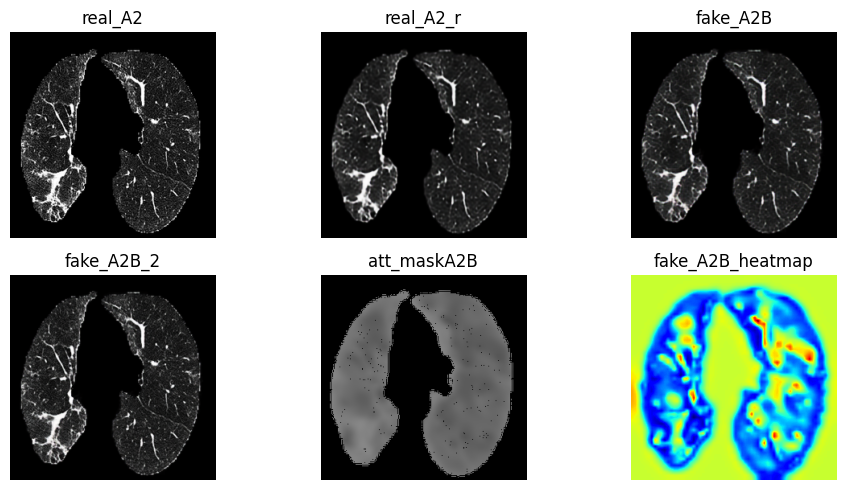

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
ax = axes.flatten()
for i, (name, img) in enumerate(imgs.items()):
    ax[i].imshow(img)
    ax[i].set_title(name)
    ax[i].axis('off')
ax[4].imshow(att_maskA2B)
ax[4].set_title('att_maskA2B')
ax[4].axis('off')
ax[5].imshow(fake_A2B_heatmap, cmap = 'jet')
ax[5].set_title('fake_A2B_heatmap')
ax[5].axis('off')
plt.tight_layout()

norm_att_maskA2B range: (0.0, 1.0)


Text(0.5, 1.0, 'overlay with r_mask')

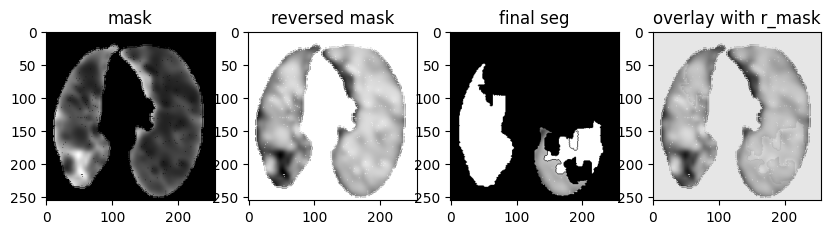

In [17]:
from findContours import water
from PIL import Image
import cv2
def norm_01(array: float):
    if array.max() - array.min() < 0.9:
        return (array - array.min()) / (array.max() - array.min())
    else:
        return array
norm_att_maskA2B = norm_01(att_maskA2B ** 5)
print(f"norm_att_maskA2B range: {norm_att_maskA2B.min(), norm_att_maskA2B.max()}")
MASKA2B_r = 1-norm_att_maskA2B
result = water((MASKA2B_r*255).astype(np.uint8))
fig, ax = plt.subplots(1, 4, figsize=(10, 5))
ax[0].imshow(norm_att_maskA2B)
ax[0].set_title('mask')
ax[1].imshow(MASKA2B_r)
ax[1].set_title('reversed mask')
ax[2].imshow(result)
ax[2].set_title('final seg')
ax[3].imshow(MASKA2B_r)
ax[3].imshow(result, alpha=0.1)  # Overlay with transparency
ax[3].set_title('overlay with r_mask')

markers3 unique: [-1  1  2  3  4  5], shape: (256, 256)


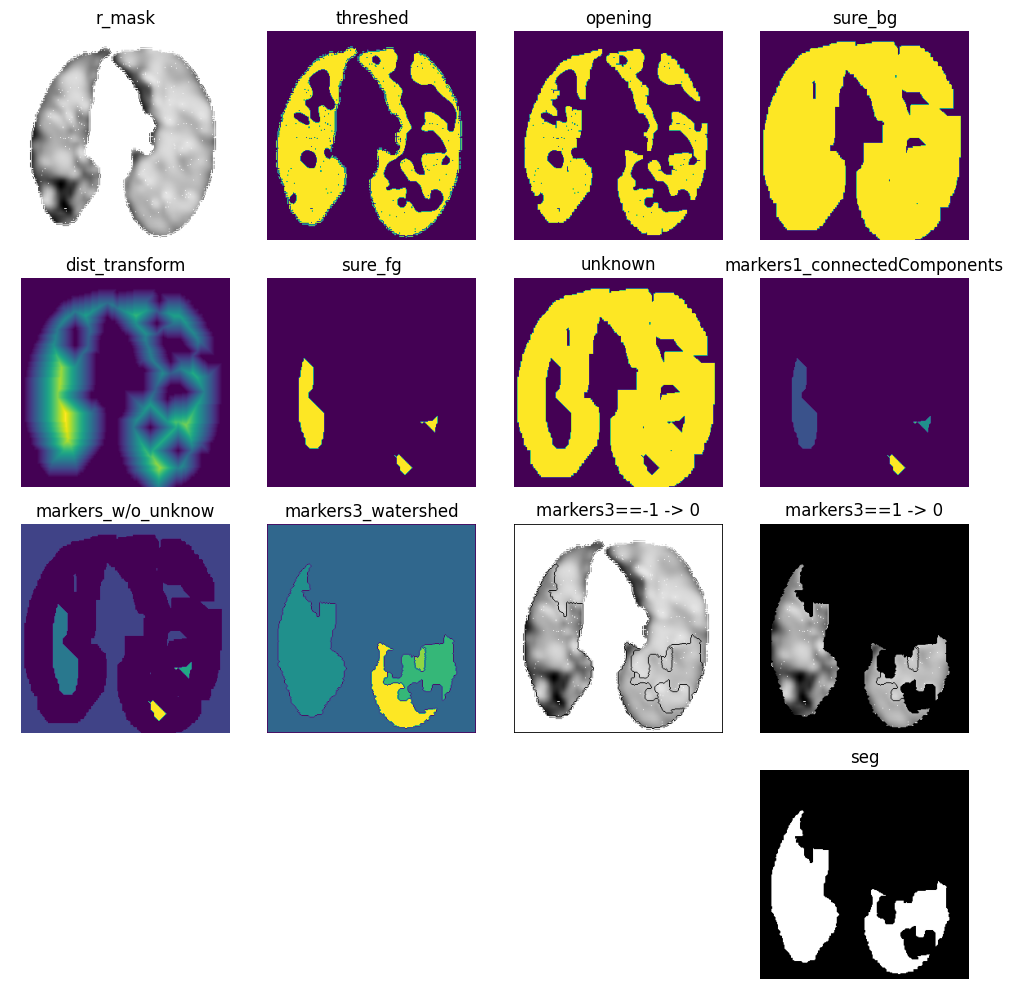

In [37]:
def water_vis(img_path):
    try:
        src = cv2.imread(img_path)
    except:
        src = img_path #directly input image
    img = src.copy()
    fig, ax = plt.subplots(4,4,figsize=(10, 10))
    ax = ax.flatten()
    ax[0].imshow(img)
    ax[0].set_title('r_mask')
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    ax[1].imshow(thresh)
    ax[1].set_title('threshed')
    # 消除噪声
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    ax[2].imshow(opening)
    ax[2].set_title('opening')
    # 膨胀
    kernel2 = np.ones((7, 7), np.uint8)
    sure_bg = cv2.dilate(opening, kernel2, iterations=3)
    ax[3].imshow(sure_bg)
    ax[3].set_title('sure_bg')
    # 距离变换
    dist_transform = cv2.distanceTransform(sure_bg, 1, 5)
    ax[4].imshow(dist_transform)
    ax[4].set_title('dist_transform')
    ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
    ax[5].imshow(sure_fg)
    ax[5].set_title('sure_fg')
    # 获得未知区域
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    ax[6].imshow(unknown)
    ax[6].set_title('unknown')
    # 标记
    ret, markers1 = cv2.connectedComponents(sure_fg)
    ax[7].imshow(markers1)
    ax[7].set_title('markers1_connectedComponents')
    # 确保背景是1不是0
    markers = markers1 + 1
    # 未知区域标记为0
    markers[unknown == 255] = 0
    ax[8].imshow(markers)
    ax[8].set_title('markers_w/o_unknow')

    markers3 = cv2.watershed(img, markers)
    print(f"markers3 unique: {np.unique(markers3)}, shape: {markers3.shape}")
    ax[9].imshow(markers3)
    ax[9].set_title('markers3_watershed')
    # -1是分割线 (edge)
    img[markers3 == -1] = [0, 0, 0]
    ax[10].imshow(img)
    ax[10].set_title('markers3==-1 -> 0')
    #1是背景
    img[markers3 == 1] = [0, 0, 0]
    ax[11].imshow(img)
    ax[11].set_title('markers3==1 -> 0')
    #234是前景
    # img[markers3 == 2] = [255, 255, 255]
    # img[markers3 == 3] = [255, 255, 255]
    # img[markers3 == 4] = [255, 255, 255]
    img[(markers3 > 1) & (markers3 <= 4)] = [255, 255, 255]
    img[markers3>4] = [255, 255, 255] #[0,0,0]
    
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=1)
    ax[15].imshow(img)
    ax[15].set_title('seg')
    
    
    for a in ax.flatten():
        a.axis('off')
    plt.tight_layout()
    
norm_att_maskA2B = norm_01(att_maskA2B) ** 5
MASKA2B_r = 1-norm_att_maskA2B
result = water_vis((MASKA2B_r*255).astype(np.uint8))

In [43]:
model_name = '_params_0009000.pt'
path = '/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/results/OSIC/val_folder_less_equal_trainA/results_mask_reverse1'
output_path = '/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/results//val_folder_less_equal_trainA/iccv_labels1'

print(any('OSIC' in item for item in (model_name, path, output_path)))


True


## Main Val

In [ ]:
from findContours import findCont
from five_metrics import five_m
from utils import cam
def norm_01(array: float):
    if array.max() - array.min() < 0.9:
        return (array - array.min()) / (array.max() - array.min())
    else:
        return array

def val(self):
    list_model = sorted(
        # glob(os.path.join(self.result_dir, self.dataset, self.folder, 'model' + str(self.stage), '*' + '000.pt'))) # get the model list each 1000.
        glob(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name, '*' + '000.pt'))) # get the model list each 1000.
    if len(list_model) == 0:
        list_model = sorted(glob(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name, '*' + '.pt')))
    max_value = [0, 0, 0, 0, 0]
    for m in list_model[-5:]:
        model_list = glob(
            os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name,
                            str(m.split('/')[-1].split('\'')[0])))
        model_name = str(m.split('/')[-1].split('\'')[0])
        if not len(model_list) == 0:
            model_list.sort()
            iter = int(model_list[-1].split('_')[-1].split('.')[0])
            iter = int('0009000')
            # iter = int('0013000')
            self.load(os.path.join(self.result_dir, self.dataset, self.folder, self.exp_name), iter)
            model_name = model_name.replace(model_name.split('_')[-1], f'{iter:07}.pt')
            
            # # load pre-trained BraTS model
            # BraTS_model_path = "/media/NAS06/gavinyue/genai-wsss/benchmarks/MedImgSeg/results/BraTS/brats_1/model1/BraTS_params_0005250.pt"
            # params = torch.load(BraTS_model_path)
            # self.genA2B.load_state_dict(params['genA2B'])
            # self.genB2A.load_state_dict(params['genB2A'])
            # self.disGA.load_state_dict(params['disGA'])
            # self.disGB.load_state_dict(params['disGB'])
            # self.disLA.load_state_dict(params['disLA'])
            # self.disLB.load_state_dict(params['disLB'])
            
            print(" [*] Load SUCCESS")
        else:
            print(" [*] Load FAILURE")
            return

        self.genA2B.eval(), self.genB2A.eval()
        for n, (real_A, _, pathA) in enumerate(self.valA_loader):
            real_A = real_A.to(self.device)
            real_A2 = real_A

            fake_A2B, cam_logit, fake_A2B_heatmap, att_maskA2B, fake_A2B_2, real_A2_r = self.genA2B(real_A2)

            pathA = pathA[0].split('/')[-1].split('.')[0] + '.' + pathA[0].split('/')[-1].split('.')[1]


            path1 = os.path.join(self.result_dir, self.dataset, self.folder, f'val_folder_{self.exp_name}',
                                    'results_mask_reverse' + str(self.stage), model_name)
            path2 = os.path.join(self.result_dir, self.dataset, self.folder, f'val_folder_{self.exp_name}',
                                    'iccv_labels' + str(self.stage), model_name)
            path3 = os.path.join(self.result_dir, self.dataset, self.folder, f'val_folder_{self.exp_name}',
                                    'results_mask' + str(self.stage), model_name)
            path4 = os.path.join(self.result_dir, self.dataset, self.folder, f'val_folder_{self.exp_name}',
                                    'heatmap_A2B' + str(self.stage), model_name)
            path5 = os.path.join(self.result_dir, self.dataset, self.folder, f'val_folder_{self.exp_name}',
                                    'fake_A2B' + str(self.stage), model_name)
            path6 = os.path.join(self.result_dir, self.dataset, self.folder, f'val_folder_{self.exp_name}',
                                    'fake_A2B_2' + str(self.stage), model_name)

            if (os.path.exists(path1) != True):
                os.makedirs(path1)
            if (os.path.exists(path2) != True):
                os.makedirs(path2)
            if (os.path.exists(path3) != True):
                os.makedirs(path3)
            if (os.path.exists(path4) != True):
                os.makedirs(path4)
            if (os.path.exists(path5) != True):
                os.makedirs(path5)
            if (os.path.exists(path6) != True):
                os.makedirs(path6)

            background = torch.zeros_like(att_maskA2B).to(self.device)
            att_maskA2B = torch.where(real_A2 > -1, att_maskA2B, background)
            
            if (self.dataset == "OSIC"):
                att_maskA2B = norm_01(att_maskA2B ** 5)

            att_maskA2B_r = 1 - att_maskA2B
            MASKA2B_r = RGB2BGR(tensor2numpy(denorm(att_maskA2B_r[0])) * 2 - 1)
            if (self.dataset == "ISIC"):
                pathA = pathA.split('.')[0]
            elif (self.dataset == "OSIC"):
                pathA = pathA.split('.')[0] #remove '.png'
≈

        root_path = os.path.join(self.result_dir, self.dataset, self.folder)
        find_path = os.path.join(path1)
        find_output_path = os.path.join(path2)
        findCont(model_name, find_path, find_output_path)
        five_pre_path = os.path.join(path2)
        five_label_path = os.path.join('dataset', self.dataset, self.folder, 'val', 'labels')
        return_value = five_m(model_name, five_pre_path, five_label_path, self.dataset, self.folder, self.stage)
        if (return_value[0] > max_value[0]):
            max_value = return_value.copy()
            with open(root_path + "/val_max.txt", "w") as f:
                f.write(self.dataset)
                f.write('\n')
                f.write(self.folder)
                f.write('\n')
                f.write(", ".join(str(i) for i in max_value))
                f.write('\n')
                f.write(model_name)
                f.write('\n')
        print(" max_value: %s " % max_value)
        print(" %s Val finished!" % (model_name))
        break
    
val(gan)

 [*] Load SUCCESS
8.33 %
16.67 %
25.0 %
33.33 %
41.67 %
50.0 %
58.33 %
66.67 %
75.0 %
83.33 %
91.67 %
100.0 %
JA:0.2320 
AC:0.8138 
DI:0.3547 
SE:0.4680 
SP:0.9082 
  JA     AC     DI      SE     SP
0.232, 0.8138, 0.3547, 0.468, 0.9082
 max_value: [0.232  0.8138 0.3547 0.468  0.9082] 
 OSIC_params_0009000.pt Val finished!


In [3]:
IoU = 0.232
2 * IoU / (1 + IoU)

0.37662337662337664